# Major Assignment – 1 (Chapter 9 – 10)
### Part B: Lab Questions

---
## Lab 1: Generate synthetic datasets for clustering

### Question:
a) Use make_blobs() to create a dataset with 3 clusters  
b) Visualize the dataset using a scatter plot.  
c) Change the number of clusters and observe the results.  

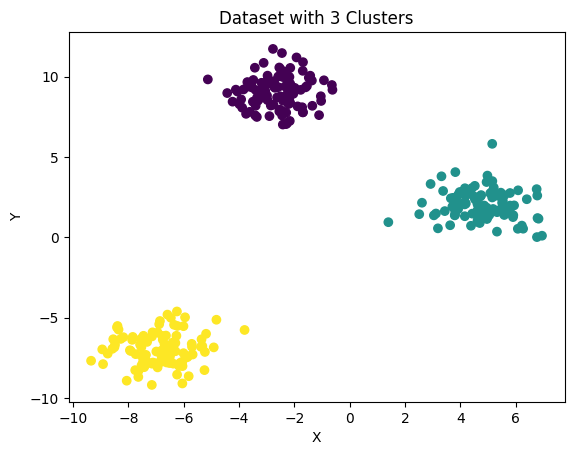

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Dataset with 3 Clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

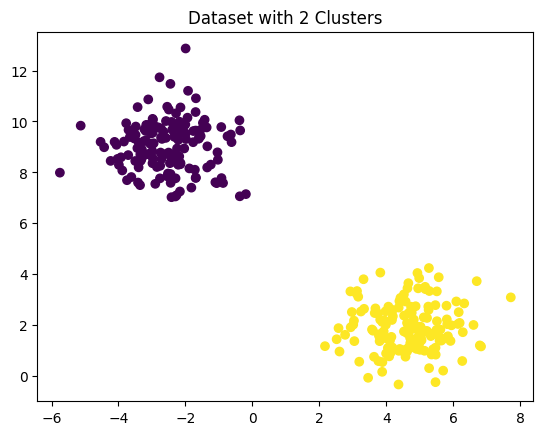

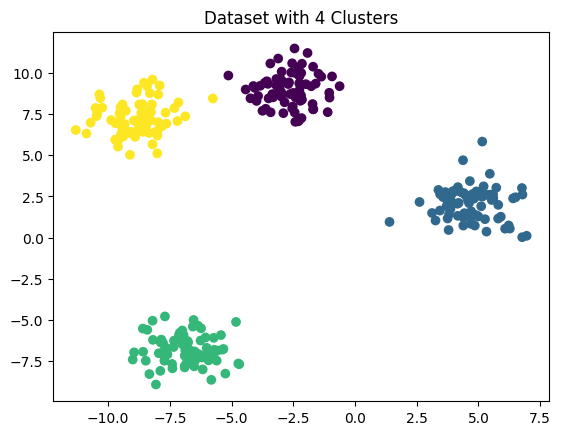

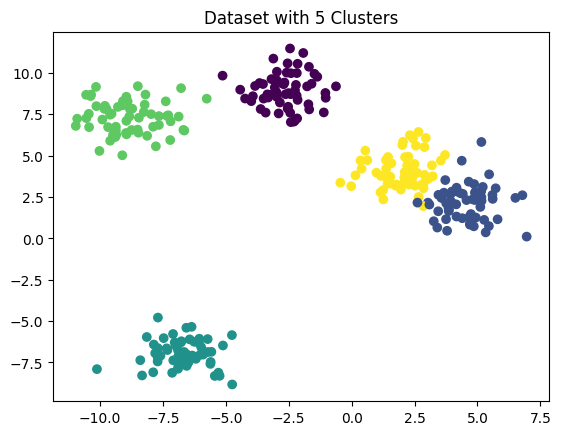

In [2]:
X, y = make_blobs(n_samples=300, centers=2, n_features=2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Dataset with 2 Clusters')
plt.show()

X, y = make_blobs(n_samples=300, centers=4, n_features=2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Dataset with 4 Clusters')
plt.show()

X, y = make_blobs(n_samples=300, centers=5, n_features=2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Dataset with 5 Clusters')
plt.show()

---
## Lab 2: Determine the optimal number of clusters using Elbow Method

### Question:
a) Generate a dataset using make_blobs().  
b) Apply K-Means for different values of k (k=1 to 9).  
c) Calculate inertia (sum of squared distances).  
d) Plot the Elbow graph.  

k=1, Inertia=20402.344442926296
k=2, Inertia=5763.4647894614345
k=3, Inertia=566.8595511244134
k=4, Inertia=497.03398814952124
k=5, Inertia=428.21421299328415
k=6, Inertia=375.0659248776243
k=7, Inertia=308.19836610418264
k=8, Inertia=272.405731498748
k=9, Inertia=234.28072349591122


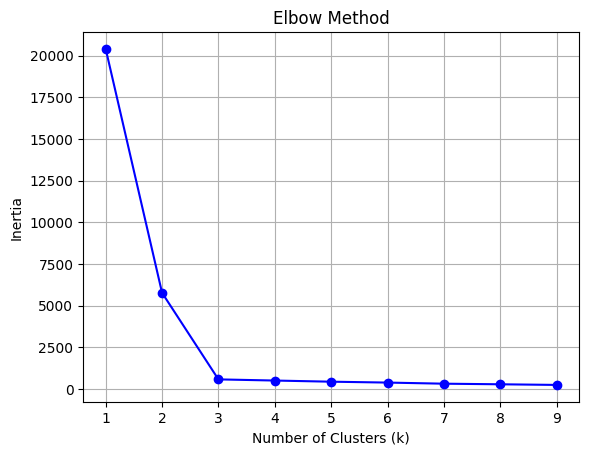

In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

inertias = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    print(f"k={k}, Inertia={kmeans.inertia_}")

plt.plot(range(1, 10), inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

---
## Lab 3: Perform clustering using K-Means on a synthetic dataset

### Question:
a) Generate a dataset using make_blobs().  
b) Apply the K-Means algorithm.  
c) Change the number of clusters from 2 to 5.  
d) Plot clusters and centroids.  
e) Observe how cluster formation changes.  

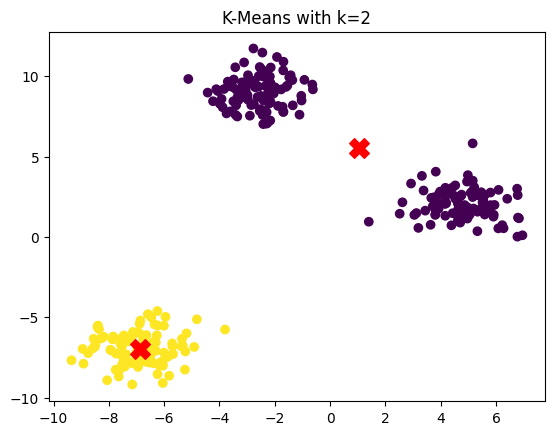

In [4]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('K-Means with k=2')
plt.show()

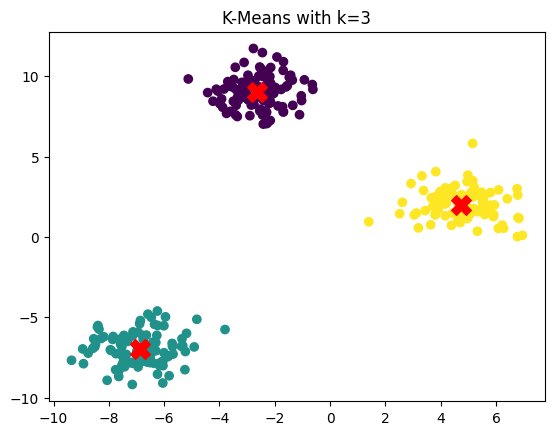

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('K-Means with k=3')
plt.show()

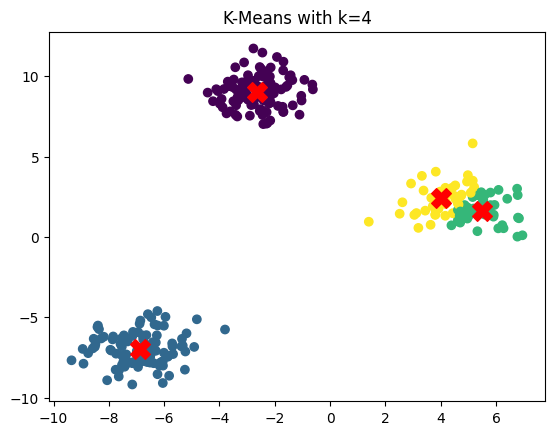

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('K-Means with k=4')
plt.show()

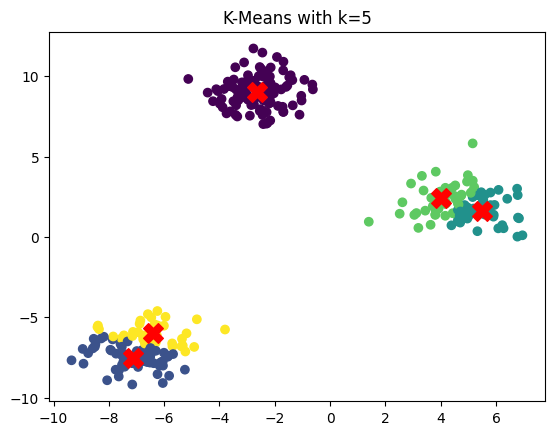

In [7]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('K-Means with k=5')
plt.show()

---
## Lab 4: Perform clustering using Hierarchical Clustering on a synthetic dataset

### Question:
a) Generate a dataset using make_blobs().  
b) Apply Agglomerative Clustering.  
c) Plot a dendrogram.  
d) Compare results with K-Means clustering.  

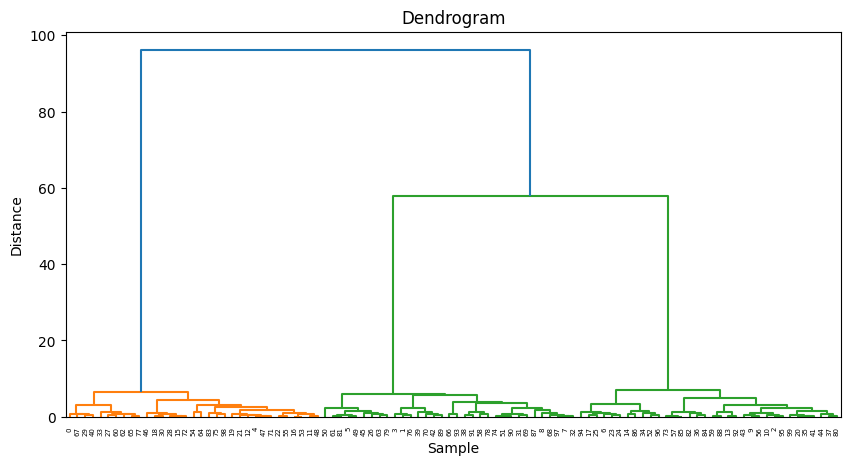

In [8]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

linkage_matrix = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix)
plt.title('Dendrogram')
plt.xlabel('Sample')
plt.ylabel('Distance')
plt.show()

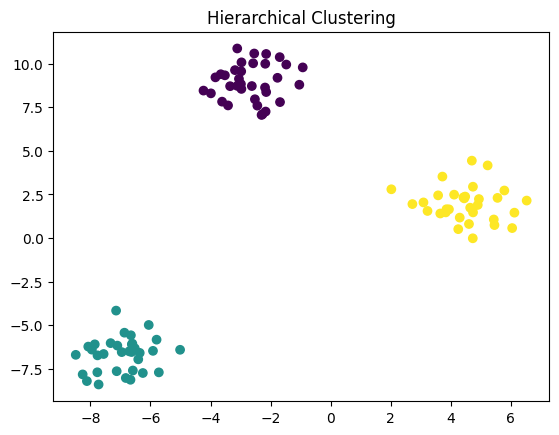

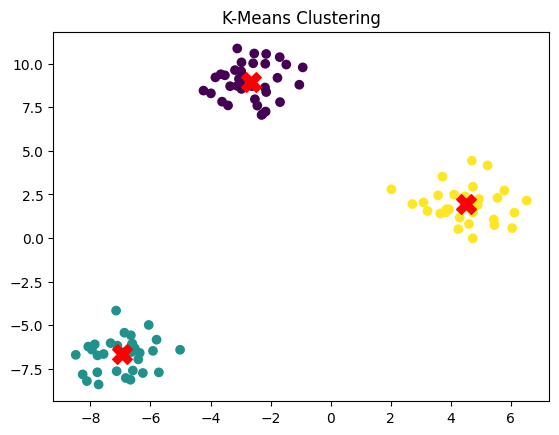

In [9]:
agg_cluster = AgglomerativeClustering(n_clusters=3)
labels_agg = agg_cluster.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_agg)
plt.title('Hierarchical Clustering')
plt.show()

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('K-Means Clustering')
plt.show()

---
## Lab 5: Find patterns using association rules

### Question:
a) Create a small transaction dataset.  
b) Apply the Apriori algorithm.  
c) Calculate support and confidence.  
d) Generate association rules.  

In [10]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
transactions = [
    ['bread', 'milk'],
    ['bread', 'butter'],
    ['milk', 'butter'],
    ['bread', 'milk', 'butter'],
    ['bread', 'milk'],
    ['milk', 'butter']
]

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

print("Transaction Data:")
print(df)
print()

Transaction Data:
   bread  butter   milk
0   True   False   True
1   True    True  False
2  False    True   True
3   True    True   True
4   True   False   True
5  False    True   True



In [11]:
frequent_itemsets = apriori(df, min_support=0.3, use_colnames=True)

print("Frequent Itemsets:")
print(frequent_itemsets)
print()

Frequent Itemsets:
    support         itemsets
0  0.666667          (bread)
1  0.666667         (butter)
2  0.833333           (milk)
3  0.333333  (butter, bread)
4  0.500000    (bread, milk)
5  0.500000   (butter, milk)



In [12]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

print("Association Rules:")
print()
for index, row in rules.iterrows():
    print(f"Rule: {row['antecedents']} => {row['consequents']}")
    print(f"Support: {row['support']:.2f}")
    print(f"Confidence: {row['confidence']:.2f}")
    print()

Association Rules:

Rule: frozenset({'butter'}) => frozenset({'bread'})
Support: 0.33
Confidence: 0.50

Rule: frozenset({'bread'}) => frozenset({'butter'})
Support: 0.33
Confidence: 0.50

Rule: frozenset({'bread'}) => frozenset({'milk'})
Support: 0.50
Confidence: 0.75

Rule: frozenset({'milk'}) => frozenset({'bread'})
Support: 0.50
Confidence: 0.60

Rule: frozenset({'butter'}) => frozenset({'milk'})
Support: 0.50
Confidence: 0.75

Rule: frozenset({'milk'}) => frozenset({'butter'})
Support: 0.50
Confidence: 0.60



---
## Lab 6: Implement Artificial Neuron Calculation

### Question:
a) Take input values x1, x2, x3.  
b) Assign weights w1, w2, w3.  
c) Compute neuron output using: y=f(w1x1+w2x2+w3x3+b)  
d) Implement it using activation functions: step, sigmoid, tanh, relu  

In [13]:
import numpy as np

x1 = 1
x2 = 2
x3 = 3

w1 = 0.5
w2 = 0.3
w3 = 0.2

bias = 0.1

z = w1*x1 + w2*x2 + w3*x3 + bias

print(f"Inputs: x1={x1}, x2={x2}, x3={x3}")
print(f"Weights: w1={w1}, w2={w2}, w3={w3}")
print(f"Bias: {bias}")
print(f"Weighted Sum: {z}")
print()

Inputs: x1=1, x2=2, x3=3
Weights: w1=0.5, w2=0.3, w3=0.2
Bias: 0.1
Weighted Sum: 1.8000000000000003



In [14]:
if z >= 0:
    step_output = 1
else:
    step_output = 0

print(f"Step Function Output: {step_output}")

Step Function Output: 1


In [15]:
sigmoid_output = 1 / (1 + np.exp(-z))

print(f"Sigmoid Output: {sigmoid_output}")

Sigmoid Output: 0.8581489350995123


In [16]:
tanh_output = np.tanh(z)

print(f"Tanh Output: {tanh_output}")

Tanh Output: 0.9468060128462683


In [17]:
if z >= 0:
    relu_output = z
else:
    relu_output = 0

print(f"ReLU Output: {relu_output}")

ReLU Output: 1.8000000000000003


---
## Lab 7: Train a perceptron classifier on a synthetic dataset

### Question:
a) Generate a dataset using make_classification().  
b) Train a perceptron classifier.  
c) Plot the decision boundary.  
d) Identify misclassified points and compute accuracy.  

In [18]:
from sklearn.datasets import make_classification
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=100, n_features=2, n_informative=2,n_redundant=0, random_state=42)

perceptron = Perceptron(max_iter=100, random_state=42)
perceptron.fit(X, y)

y_pred = perceptron.predict(X)

accuracy = sum(y == y_pred) / len(y)

print(f"Accuracy: {accuracy}")
print()

Accuracy: 0.98



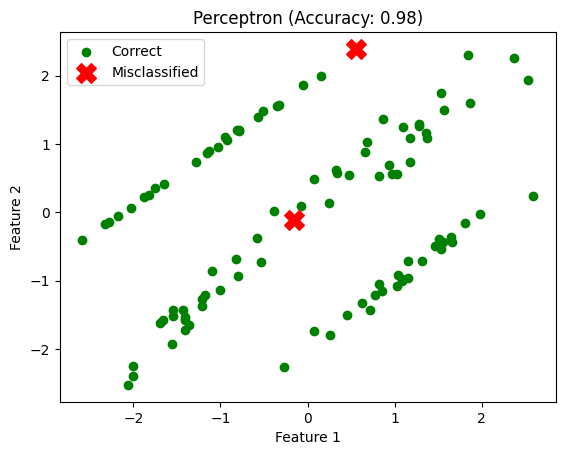

Number of Misclassified Points: 2


In [19]:
misclassified = y != y_pred

plt.scatter(X[~misclassified, 0], X[~misclassified, 1], c='green', label='Correct')
plt.scatter(X[misclassified, 0], X[misclassified, 1], c='red', marker='X', s=200, label='Misclassified')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Perceptron (Accuracy: {accuracy})')
plt.legend()
plt.show()

print(f"Number of Misclassified Points: {sum(misclassified)}")

---
## Lab 8: Implement a neural network classifier using MLPClassifier

### Question:
a) Create a dataset.  
b) Train a neural network classifier.  
c) Change number of hidden layers.  
d) Compare model accuracy.  

In [20]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

model1 = MLPClassifier(hidden_layer_sizes=(4,), solver='lbfgs', max_iter=1000, random_state=42)
model2 = MLPClassifier(hidden_layer_sizes=(8,4), solver='lbfgs', max_iter=1000, random_state=42)

model1.fit(X, y)
model2.fit(X, y)

pred1 = model1.predict(X)
pred2 = model2.predict(X)

print("Model 1 Accuracy:", accuracy_score(y, pred1))
print("Model 2 Accuracy:", accuracy_score(y, pred2))

Model 1 Accuracy: 0.75
Model 2 Accuracy: 0.5


---
## Lab 9: Design a neural network with one hidden layer and train using backpropagation

### Question:
a) Create a dataset with two classes.  
b) Design neural network: input layer, one hidden layer, output layer.  
c) Perform forward propagation.  
d) Apply backpropagation to train and evaluate accuracy.  

In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

X = np.array([[0,0],[0,1],[1,0],[1,1],[0,2],[2,0]])
y = np.array([0,1,1,0,1,1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.5


---
## Lab 10: Complete ML Workflow

### Question:
a) Generate dataset.  
b) Perform clustering to identify patterns.  
c) Train perceptron classifier.  
d) Train neural network classifier.  
e) Compare results.  

In [22]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

X, y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=10)

kmeans = KMeans(n_clusters=2, random_state=10)
clusters = kmeans.fit_predict(X)

p = Perceptron(max_iter=1000, random_state=10)
p.fit(X, y)
pred_p = p.predict(X)

nn = MLPClassifier(hidden_layer_sizes=(6,), solver='lbfgs', max_iter=1000, random_state=10)
nn.fit(X, y)
pred_nn = nn.predict(X)

print("Perceptron Accuracy:", accuracy_score(y, pred_p))
print("Neural Network Accuracy:", accuracy_score(y, pred_nn))

Perceptron Accuracy: 1.0
Neural Network Accuracy: 1.0
